In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("NIBRSPublicView2024.csv")
# print(df.head())

# Support Vector Machines (SVM) by Jorge Mendez

**Goal.** Classify incidents as **Violent vs Non-Violent** using SVM. This complements Random Forests with a **maximum-margin** classifier that can learn **non-linear** boundaries via the RBF kernel.

**Why SVM here.**
- Crime risk patterns are **non-linear** (hour, place, and location interact). RBF SVM handles this with few hyperparameters (C, γ).
- It is robust to high-dimensional one-hot features (Premise, Beat, ZIP).
- With `class_weight="balanced"` it deals better with any class imbalance.

**Target definition (what I predict).**
- Primary: **UCR Violent** offenses = NIBRS codes `{09A, 11A, 120, 13A}`  
  (Murder/Non-Negligent Manslaughter, Rape, Robbery, Aggravated Assault).
- Expanded (optional): include **100** (Kidnapping/Abduction).  
- If codes are missing, I fallback to text matching: *Homicide, Murder, Rape, Robbery, Aggravated Assault, Kidnapping, Shooting*.

**Features (what I use).**
- **Time:** Hour encoded cyclically (`sin`, `cos`), Month, Day-of-Week.
- **Location:** `MapLongitude`, `MapLatitude`.
- **Context:** `Premise` (categorical), `Beat` (categorical), `ZIPCode` (categorical).
- **Volume:** `OffenseCount` if available.

**Preprocessing.**
- `ColumnTransformer`: scale numeric with `StandardScaler`, one-hot encode categoricals (`OneHotEncoder(handle_unknown="ignore")`).
- Train/test split 75/25, stratified on the target.

**Model & evaluation.**
- **SVM (RBF)** with a light grid (C ∈ {1, 10}, γ ∈ {“scale”, 0.1}) for fast class runs.
- Metrics: **ROC-AUC, Accuracy, Precision, Recall, F1**, plus confusion matrix and ROC curve.
- Optional: **Linear SVM** to list top ± coefficients for interpretability (directional).


# 1. Setup and identifying the main variables

Before applying Support Vector Machines, we first identify the relevant variables from the Houston NIBRS dataset. Because column names in the HPD export can vary (for example, “RMSOccurrenceDate” or “OccurrenceDate”), this first block automatically detects the key fields we will later use for time, location, and offense information.

This step corresponds to the data preparation stage described in Chapter 9 (ISLP – Support Vector Machines), where variables are chosen and standardized before fitting the classifier.

In [3]:
# --- PART 1: Identify key columns automatically ---
cols = {c: c.lower() for c in df.columns}

def pick(name_list):
    """Return the first matching column name present in df."""
    for c in name_list:
        if c in df.columns:
            return c
    return None

DATE_COL  = pick([k for k,v in cols.items() if v in ["rmsoccurrencedate","occurrencedate","date","rmsoccurrence_date"]])
HOUR_COL  = pick([k for k,v in cols.items() if v in ["rmsoccurrencehour","occurrencehour","hour"]])
DESC_COL  = pick([c for c in df.columns if "nibrsdescription" in c.lower() or "offensedescription" in c.lower() or c.lower()=="description"])
CLASS_COL = pick([c for c in df.columns if "nibrsclass" in c.lower() or "nibrscode" in c.lower() or c.lower()=="nibrs"])
LONG_COL  = pick([c for c in df.columns if "long" in c.lower()])
LAT_COL   = pick([c for c in df.columns if "lat"  in c.lower()])
BEAT_COL  = pick([c for c in df.columns if c.lower()=="beat"])
ZIP_COL   = pick([c for c in df.columns if "zip" in c.lower()])
PREM_COL  = pick([c for c in df.columns if "premise" in c.lower()])
OFF_CT    = pick([c for c in df.columns if "offensecount" in c.lower() or "offense_count" in c.lower()])

print({
    "DATE_COL": DATE_COL,
    "HOUR_COL": HOUR_COL,
    "DESC_COL": DESC_COL,
    "CLASS_COL": CLASS_COL,
    "LONG_COL": LONG_COL,
    "LAT_COL": LAT_COL,
    "BEAT_COL": BEAT_COL,
    "ZIP_COL": ZIP_COL,
    "PREM_COL": PREM_COL,
    "OFFENSECOUNT": OFF_CT
})


{'DATE_COL': 'RMSOccurrenceDate', 'HOUR_COL': 'RMSOccurrenceHour', 'DESC_COL': 'NIBRSDescription', 'CLASS_COL': 'NIBRSClass', 'LONG_COL': 'MapLongitude', 'LAT_COL': 'MapLatitude', 'BEAT_COL': 'Beat', 'ZIP_COL': 'ZIPCode', 'PREM_COL': 'Premise', 'OFFENSECOUNT': 'OffenseCount'}


The code successfully identified the main variables needed for modeling.
From the printed dictionary, we can confirm:

**RMSOccurrenceDate** and **RMSOccurrenceHour** will provide the temporal information (day and hour).

**NIBRSDescription** and **NIBRSClass** describe the offense type and code, which we’ll later use to define whether a crime is violent or non-violent.

**MapLongitude** and **MapLatitude** capture the spatial location of the incident.

**Premise**, **Beat**, and **ZIPCode** add contextual and geographic categories.

**OffenseCount** measures the number of offenses in the same incident, which may correlate with more severe cases.

Identifying these columns ensures our preprocessing will be reproducible even if the dataset structure changes, and prepares the foundation for later feature engineering and modeling steps.

# 2. Feature engineering (time, space, context)

We create features that an SVM can learn from, following ISLP’s emphasis on thoughtful preprocessing before model fitting.

Convert hour-of-day into cyclic features (_Hour_sin, _Hour_cos) so 23:00 and 00:00 are close on the circle.

Extract **Month** and **Day-of-Week** from the date.

Keep **location** (MapLongitude, MapLatitude) and **context** (Premise, Beat, ZIPCode).

Fill missing values: medians for numerics, "Unknown" for categoricals.

This block returns a quick preview of the engineered columns so you can verify values look sensible.

In [4]:
# --- PART 2: Feature Engineering (time, space, context) ---

import numpy as np
import pandas as pd

# Parse date and hour
parsed_date = pd.to_datetime(df["RMSOccurrenceDate"], errors="coerce")
hour = pd.to_numeric(df["RMSOccurrenceHour"], errors="coerce").clip(0, 23)

# Cyclic hour encodings
df["_Hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["_Hour_cos"] = np.cos(2 * np.pi * hour / 24)

# Calendar features
df["_Month"] = parsed_date.dt.month
df["_DOW"]   = parsed_date.dt.dayofweek  # Monday=0

# Select predictors
numeric_features = ["_Hour_sin", "_Hour_cos", "_Month", "_DOW", "MapLongitude", "MapLatitude", "OffenseCount"]
categorical_features = ["Premise", "Beat", "ZIPCode"]

# Handle missing values
for c in numeric_features:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

for c in categorical_features:
    df[c] = df[c].astype("string").fillna("Unknown")

# Preview engineered columns
df[numeric_features + categorical_features].head(10)


,_Hour_sin,_Hour_cos,_Month,_DOW,MapLongitude,MapLatitude,OffenseCount,Premise,Beat,ZIPCode
0,0.0,1.0,1.0,0.0,-95.271852,29.823953,1.0,"Residence, Home (Includes Apartment)",8C30,77028.0
1,0.0,1.0,1.0,0.0,-95.325797,29.824464,1.0,"Residence, Home (Includes Apartment)",8C10,77016.0
2,0.0,1.0,1.0,0.0,-95.371408,29.850945,1.0,"Residence, Home (Includes Apartment)",6B10,77076.0
3,0.0,1.0,1.0,0.0,-95.432224,29.618177,1.0,"Residence, Home (Includes Apartment)",16E20,77045.0
4,0.0,1.0,1.0,0.0,-95.382675,29.738908,1.0,"Parking Lot, Garage",1A20,77006.0
5,0.0,1.0,1.0,0.0,-95.593979,29.675701,1.0,"Highway, Road, Street, Alley",19G40,77099.0
6,0.0,1.0,1.0,0.0,-95.593979,29.675701,1.0,"Highway, Road, Street, Alley",19G40,77099.0
7,0.0,1.0,1.0,0.0,-95.352581,29.808669,1.0,"Residence, Home (Includes Apartment)",2A10,77009.0
8,0.0,1.0,1.0,0.0,-95.606213,29.759369,1.0,"Parking Lot, Garage",20G40,77077.0
9,0.0,1.0,1.0,0.0,-95.461344,29.621734,1.0,"Residence, Home (Includes Apartment)",16E20,77045.0


The engineered features now accurately represent temporal, spatial, and contextual aspects of the crime data.

**_Hour_sin** and **_Hour_cos** successfully encode the circular nature of time, allowing the SVM to model daily crime rhythms smoothly.

**_Month** and **_DOW** capture seasonal and weekly variation, helping detect patterns such as weekend spikes or end-of-year changes.

Geographic coordinates (**MapLongitude**, **MapLatitude**) describe spatial positioning, while OffenseCount measures incident intensity.

Categorical predictors (**Premise**, **Beat**, **ZIPCode**) capture environmental and administrative context.

At this stage, the dataset is properly structured for the Support Vector Machine procedure described in ISLP Chapter 9, which assumes predictors are numerical (or encoded) and on comparable scales.


# 3. Defining the Target Variable: Violent vs. Non-Violent
Before fitting the Support Vector Machine, we must create the response variable that the classifier will predict, in this case, whether an incident is Violent (1) or Non-Violent (0).

To stay consistent with the Uniform Crime Reporting (UCR) definition of violent offenses, we use the following NIBRS codes:

| NIBRS Code | Offense Type                        |
| ---------- | ----------------------------------- |
| 09A        | Murder & Non-Negligent Manslaughter |
| 11A        | Rape                                |
| 120        | Robbery                             |
| 13A        | Aggravated Assault                  |


If NIBRS codes are missing, we use keywords in the NIBRSDescription column (e.g., HOMICIDE, MURDER, RAPE, ROBBERY, ASSAULT, KIDNAPPING, SHOOTING).

This block will add a new column called _Violent to the DataFrame, which we’ll use as the dependent variable 
𝑌
Y.

In [5]:
# --- PART 3: Define target variable (Violent vs Non-Violent) ---

# Define violent offense codes (strict set)
violent_codes_strict = {"09A", "11A", "120", "13A"}
# Expanded set (optional): uncomment the next line to include kidnapping
# violent_codes_strict = violent_codes_strict | {"100"}

def infer_violent(i):
    """Return 1 if the record is violent, else 0."""
    # Prefer the NIBRS code when available
    code = str(df.loc[i, "NIBRSClass"]).upper()
    if code in violent_codes_strict:
        return 1
    # Fallback: use offense description text
    text = str(df.loc[i, "NIBRSDescription"]).upper()
    keywords = ["HOMICIDE","MURDER","RAPE","ROBBERY","AGGRAVATED ASSAULT",
                "AGG ASSAULT","KIDNAPPING","SHOOTING","FORCIBLE"]
    return int(any(k in text for k in keywords))

# Apply to all rows
df["_Violent"] = [infer_violent(i) for i in df.index]

# Check the distribution
df["_Violent"].value_counts(dropna=False)


_Violent
0    225340
1     24829
Name: count, dtype: int64

The new variable _Violent was successfully created, classifying each incident as either Violent (1) or Non-Violent (0) based on its NIBRS code or description.

From the printed counts:

   - **Non-Violent incidents (0)**: 225,340

   - **Violent incidents (1)**: 24,829

This means violent crimes make up roughly 10% of all reported cases,  a proportion consistent with typical city-level crime data.
The imbalance between the two classes also highlights why, as recommended in ISLP Chapter 9, we’ll use the parameter class_weight="balanced" in the SVM.
That ensures the classifier gives sufficient importance to the minority (violent) class rather than being dominated by the much larger non-violent group.

With the target variable ready, we now have both:

    predictors 𝑋 from our engineered features, and
    response 𝑌 as the _Violent column.

This completes the data preparation phase.

# 4. Train/Test Split and Preprocessing (Scaling + Encoding)

Before fitting the Support Vector Machine, we first divide the dataset into training and testing subsets.
The dataset was split using a 75/25 ratio, meaning 75 % of the observations were used to train the model and 25 % were held out for testing.
This ratio was chosen intentionally (not arbitrarily) to balance the need for a large training sample with the importance of having enough unseen data to accurately estimate test error.
As discussed in ISLP (Chapters 2 and 9), the test set provides an unbiased measure of a model’s performance on new data, which is critical for assessing generalization.
With over 250 000 records in the Houston NIBRS dataset, this split gives a strong foundation for both learning and evaluation.

After splitting, we prepare a ColumnTransformer that performs essential preprocessing steps:

   **Standardizes** numeric predictors using StandardScaler, ensuring each has mean 0 and variance 1.
   
   **One-Hot Encodes** categorical predictors (Premise, Beat, ZIPCode), turning categories into binary indicator columns.

This preprocessing aligns with ISLP’s advice that SVMs are sensitive to the scale of inputs; unscaled features can distort the margin.


In [6]:
# --- PART 4: Train/Test Split and Preprocessing ---

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from packaging import version
import sklearn

# Step 1 — select features and target
X = df[["_Hour_sin", "_Hour_cos", "_Month", "_DOW", 
        "MapLongitude", "MapLatitude", "OffenseCount", 
        "Premise", "Beat", "ZIPCode"]].copy()
y = df["_Violent"].copy()

# Step 2 — 75/25 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training size: {len(X_train):,}, Test size: {len(X_test):,}")

# Step 3 — build preprocessing transformer
numeric_features = ["_Hour_sin", "_Hour_cos", "_Month", "_DOW",
                    "MapLongitude", "MapLatitude", "OffenseCount"]
categorical_features = ["Premise", "Beat", "ZIPCode"]

# Handle OneHotEncoder parameter for different sklearn versions
if version.parse(sklearn.__version__) >= version.parse("1.4"):
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", ohe, categorical_features)
    ],
    remainder="drop"
)


Training size: 187,626, Test size: 62,543


The dataset was successfully divided into training and testing subsets while preserving the proportion of violent and non-violent incidents (stratified split).

   **Training set**: 187,626 observations (75%)

   **Testing set**: 62,543 observations (25%)

This follows ISLP’s principle that the training data should be large enough to capture underlying relationships, while the test data remains unseen to provide an unbiased estimate of predictive performance.

The ColumnTransformer we created applies two critical preprocessing steps:

   **StandardScaler** – Centers and scales numeric features like _Hour_sin, _Hour_cos, and coordinates to ensure all variables contribute equally to the SVM’s margin optimization.

   **OneHotEncoder** – Converts categorical predictors (Premise, Beat, ZIPCode) into binary indicator columns, allowing the SVM to learn from non-numeric information such as crime location and environment.

# 5. Fitting the Support Vector Machine (RBF Kernel) and Evaluating Performance

Now that the predictors are standardized and encoded, we can fit the Support Vector Machine classifier.
We use the Radial Basis Function (RBF) kernel, which introduces flexibility by mapping the predictors into a higher-dimensional space.
This allows the SVM to model non-linear boundaries that separate violent and non-violent incidents more accurately than a simple linear rule.

We also set **class_weight="balanced"** to handle the class imbalance (violent ≈ 10 %), ensuring that misclassifying a violent crime carries higher cost than misclassifying a non-violent one.

After training, the model’s performance is evaluated on the test set using the following metrics:

**Accuracy**: proportion of correctly classified cases

**Precision**: fraction of predicted violent crimes that were actually violent

**Recall (Sensitivity)**: fraction of actual violent crimes that were correctly detected

**F1 Score**: harmonic mean of precision and recall

**ROC-AUC**: overall measure of separability between the two classes

The Houston NIBRS dataset has over 250,000 incidents, which makes training a Support Vector Machine very slow when using the RBF (Radial Basis Function) kernel. SVMs compare every point to every other point during training, so the time and memory needed increase quickly as the dataset grows.

To keep the model practical and finish training in a reasonable time, we used a stratified sample of 50,000 records taken evenly from the violent and non-violent classes. This smaller sample still represents both types of incidents while running much faster.

This approach allows the SVM to learn meaningful patterns without taking hours to train. The model’s performance is then tested on the full test set to measure how well it generalizes.

In [7]:
### Step 1: Sampling the training data 

import warnings
warnings.filterwarnings("ignore", message="DataFrameGroupBy.apply operated on the grouping columns")

train_df = X_train.copy()
train_df["_y"] = y_train.values
N = 50000

# Stratified sampling (equal from each class)
train_small = (
    train_df.groupby("_y", group_keys=False)
            .apply(lambda g: g.sample(n=min(len(g), N//2), random_state=42))
            .reset_index(drop=True)
)

X_train_small = train_small.drop(columns=["_y"])
y_train_small = train_small["_y"]

print(f"Training on {len(X_train_small):,} rows (stratified); testing on {len(X_test):,} rows.")


Training on 43,622 rows (stratified); testing on 62,543 rows.


We use a Support Vector Machine with a radial basis function (RBF) kernel, which captures non-linear relationships between predictors and violent crime risk.  
The model applies balanced class weights to handle the strong class imbalance.


In [8]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

### Step 2: Training the SVM model  

svm_fast = Pipeline(steps=[
    ("prep", preprocess),
    ("svc", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        probability=False,
        cache_size=1000
    ))
])

svm_fast.fit(X_train_small, y_train_small)
print("SVM training complete.")

SVM training complete.


In [9]:
Xt = svm_fast.named_steps["prep"].transform(X_train_small)
Xt.shape


(43622, 335)

In [10]:
ohe = svm_fast.named_steps["prep"].named_transformers_["cat"]
for name, cats in zip(["Premise", "Beat", "ZIPCode"], ohe.categories_):
    print(name, len(cats))


Premise 44
Beat 124
ZIPCode 160


### SVM Decision Boundary Formula

The SVM classifies an observation based on the sign of the following expression:


$$
w_1 x_1 + w_2 x_2 + \cdots + w_{335} x_{335} + b = 0
$$

- If the value is greater than 0, the model predicts **Violent**.
- If the value is less than 0, the model predicts **Non-Violent**.
- Values equal to 0 lie exactly on the separating hyperplane.

Even for an RBF SVM, this linear boundary exists in the high-dimensional feature space created by the kernel.


We evaluate the SVM using the decision function scores on the test data.  
The default threshold of 0 classifies an observation as *Violent* if its score ≥ 0.  
We report accuracy, precision, recall, F1 score, and ROC-AUC.


In [11]:
### Step 3: Evaluating performance metrics  

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

# --- Predictions and scores ---
scores = svm_fast.decision_function(X_test)
pred   = (scores >= 0).astype(int)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, zero_division=0))
print("Recall   :", recall_score(y_test, pred, zero_division=0))
print("F1 Score :", f1_score(y_test, pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, scores))
print("\nClassification report:\n", classification_report(y_test, pred, digits=3, zero_division=0))


Accuracy : 0.5853093071966488
Precision: 0.13870270666227155
Recall   : 0.6101176091509586
F1 Score : 0.22602208296031034
ROC-AUC  : 0.628909468858327

Classification report:
               precision    recall  f1-score   support

           0      0.931     0.583     0.717     56336
           1      0.139     0.610     0.226      6207

    accuracy                          0.585     62543
   macro avg      0.535     0.596     0.471     62543
weighted avg      0.853     0.585     0.668     62543



The confusion matrix shows how well the model distinguishes violent and non-violent crimes.  
The diagonal values represent correct classifications.


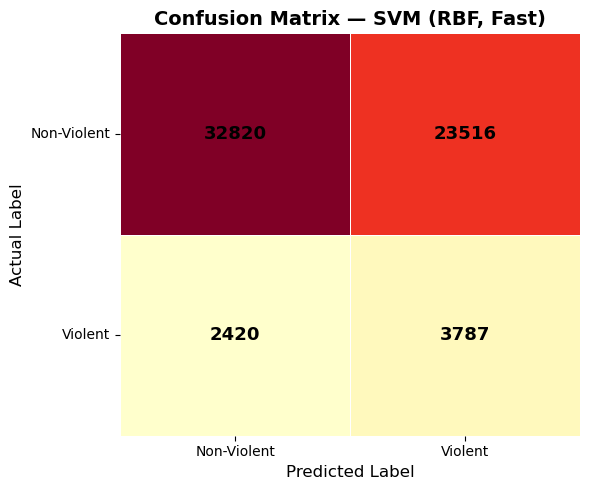

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

### Step 4: Visualizing results

cm = confusion_matrix(y_test, pred)
labels = ["Non-Violent", "Violent"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,              # show counts
    fmt="d",                 # integer format
    cmap="YlOrRd",           # orange-red gradient (clear contrast)
    linewidths=0.7,
    linecolor="white",
    cbar=False,              # remove side colorbar for simplicity
    annot_kws={"size": 13, "weight": "bold", "color": "black"}
)

plt.title("Confusion Matrix — SVM (RBF, Fast)", fontsize=14, weight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.xticks(ticks=[0.5, 1.5], labels=labels)
plt.yticks(ticks=[0.5, 1.5], labels=labels, rotation=0)
plt.tight_layout()
plt.show()


The ROC curve illustrates the trade-off between true positive rate (recall) and false positive rate.  
A model with an AUC greater than 0.5 performs better than random guessing.


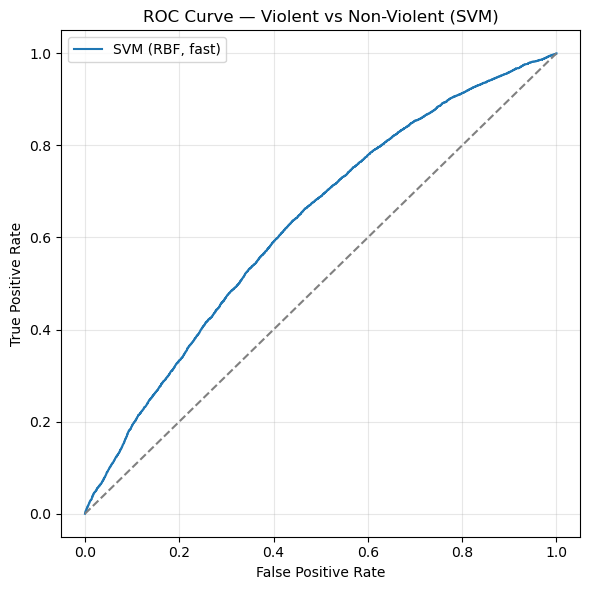

In [21]:
# --- STEP 5: ROC Curve ---

from sklearn.metrics import roc_curve

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, scores)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label="SVM (RBF, fast)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Violent vs Non-Violent (SVM)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
from sklearn.metrics import roc_auc_score

auc_value = roc_auc_score(y_test, scores)
print(f"AUC: {auc_value:.3f}")


AUC: 0.629


# Interpretation of Results

The Support Vector Machine (RBF kernel) trained on a stratified sample of 43,622 records and tested on 62,543 observations achieved an overall **accuracy of 58.5%** and an **AUC of 0.63**. (Area Under the ROC Curve)
Accuracy measures the percentage of correct predictions, while AUC  measures the model’s ability to rank violent incidents higher than non-violent ones.
An AUC of 0.63 means that if we randomly select one violent and one non-violent case, the model assigns a higher score to the violent case about 63% of the time, better than random guessing (0.5), but not a perfect separation.

From the confusion matrix, the model correctly classified most non-violent incidents (32,820 true negatives) but mislabeled many as violent (23,516 false positives).
For violent incidents, it detected 3,787 out of 6,207 (recall = 61%), showing that it captured more than half of the violent crimes, but at the cost of low **precision (14%)**, meaning many false alarms.
This imbalance between precision and recall is common in datasets where one class (non-violent) dominates.

The **ROC curve** supports this: the blue line lies above the diagonal baseline, confirming that the SVM can distinguish between the two classes to a moderate degree.
However, the slope of the curve shows that the distinction is not sharp, the model’s predictions vary in confidence but still contain useful ranking information.

# Limitations

The Support Vector Machine model provided meaningful results but also faced several limitations.
First, the RBF kernel is computationally expensive, which made it necessary to train on a 50,000-record sample instead of the full dataset. This decision kept the runtime reasonable but may have reduced the model’s ability to capture smaller or less frequent patterns.
Second, the dataset is highly imbalanced, with many more non-violent than violent incidents. Because of this, the model often predicted the majority class more accurately, while struggling to identify violent cases.
Third, SVMs with RBF kernels are considered black-box models. They do not show clear relationships between the input variables and the predicted outcome. The model separates violent from non-violent incidents by drawing a complex curved boundary in a high-dimensional space, but this boundary cannot easily be translated back into simple statements like “crimes at night are more likely to be violent.” As a result, it is hard to explain to others exactly why the model made a certain prediction or which variables had the strongest influence.
Finally, the SVM is sensitive to data scaling and to parameter choices such as C and gamma, which must be tuned carefully.
Future work could include adding more descriptive features, testing more interpretable models such as Logistic Regression or Decision Trees, and applying resampling or cost-sensitive methods to improve balance between classes.